In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
#df.drop(DROP_COLS,axis=1,inplace=True)
DROP_COLS=["PassengerId","Name","Ticket"]
def drop_cols(df:pd.DataFrame,cols:list[str])->pd.DataFrame:
    return df.drop(columns=cols,inplace=True)

drop_cols(df,DROP_COLS)

In [4]:
dtype = df.dtypes
n_unique = df.nunique()
pd.DataFrame({"Dtyps ":dtype,"N_uniques ":n_unique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtyps,int64,int64,str,float64,int64,int64,float64,str,str
N_uniques,2,3,2,88,7,7,248,147,3


In [5]:
cols=['Survived','Pclass','Sex','SibSp','Parch','Embarked']
df[cols]=df[cols].astype("category")
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,str,category


In [6]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    category
 5   Parch     891 non-null    category
 6   Fare      891 non-null    float64 
 7   Cabin     204 non-null    str     
 8   Embarked  889 non-null    category
dtypes: category(6), float64(2), str(1)
memory usage: 26.7 KB


In [7]:
null_values =df.isnull().sum()
ratio=(null_values/df.shape[0])*100
pd.DataFrame({"null ":null_values,"ratio ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [8]:
df.dropna(subset=['Embarked'])
df.drop('Cabin', axis=1, inplace=True)

In [9]:
median =df['Age'].median()
df['Age']=df['Age'].fillna(median)

In [ ]:
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    #print(Q1,Q3)
    IQR=Q3-Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR

    lower_outliers= df[df[col] < lower_fence][cols].values
    upper_outliers= df[df[col] > upper_fence][cols].values

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

In [16]:
df.duplicated().sum()

np.int64(116)

In [17]:
df.drop_duplicates(inplace=True)

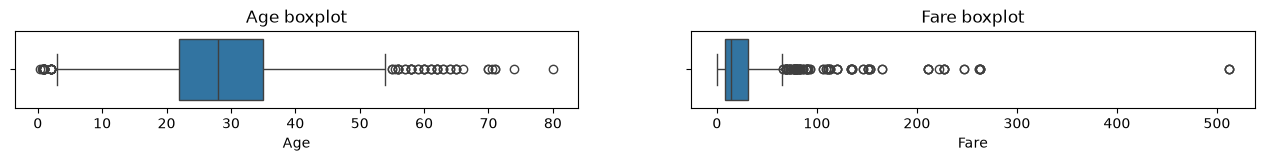

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols= df.select_dtypes('number').columns
plt.figure(figsize=(8*len(num_cols),1))
for i, col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(x=df[col],orient='h')
    plt.title(f"{col} boxplot")

In [ ]:
df remove_duplicate(df, subset_cols= None,keep_stratgy = "first"):
    
    return (df.drop_duplicates(subset=subset_cols, keep=keep_stratgy).reset_index(drop = True))

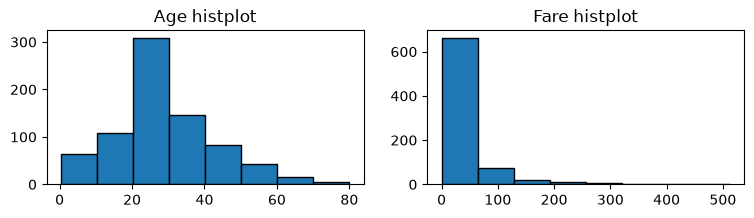

In [20]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col],edgecolor='black',bins=8)
    plt.title(f"{col} histplot")


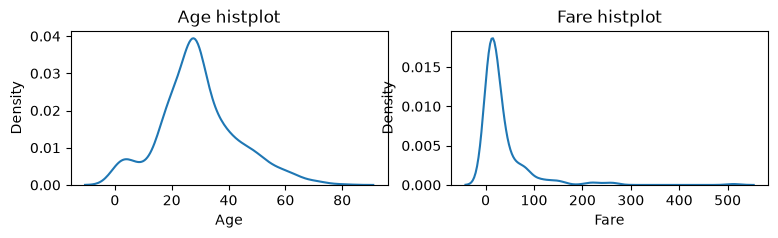

In [25]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} histplot")


In [26]:
cat_cols = df.select_dtypes('category').columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

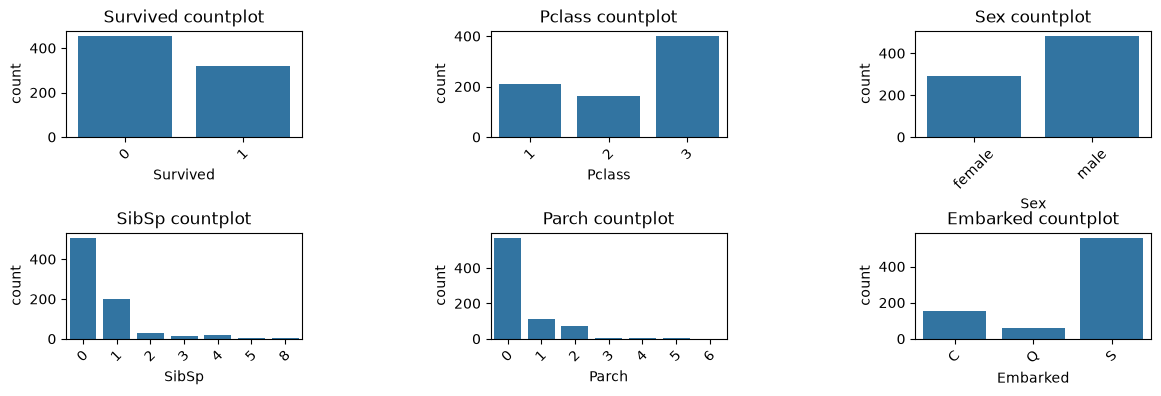

In [47]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col,data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} countplot")
    plt.subplots_adjust(hspace=.9,wspace=.8)

In [ ]:
unique=df['Servived'].value_counts()
count=unique.values
categories=unique.index

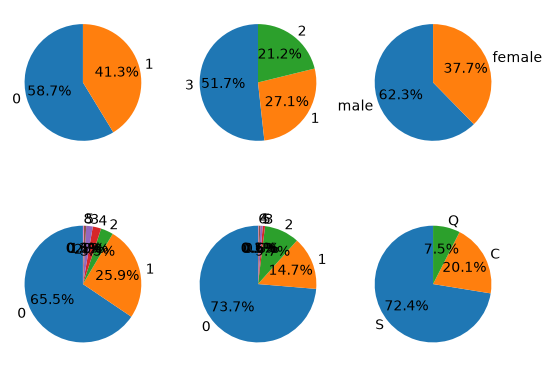

In [49]:
for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    unique=df[col].value_counts()
    count=unique.values
    categories=unique.index
    plt.pie(count,labels=categories,autopct='%.1f%%',startangle=90)
    

In [55]:
import plotly.express as px
fig = px.pie(df, names = "Survived",
       title="<b> survived pie plot</b>",
       color_discrete_sequence=px.colors.qualitative.Pastel,
       hole=0.7
       
       )
fig.update_layout(annotations = [dict(text= "Survived", font_size=20, x=0.5, y =0.5, showarrow = False)])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
              'hole': 0.7,
              'hovertemplate': 'Survived=%{label}<extra></extra>',
              'labels': {'bdata': ('AAEBAQAAAAABAQEBAAAAAQABAAEAAQ' ... 'ABAQABAQAAAQEAAQEAAAAAAQABAA=='),
                         'dtype': 'i1'},
              'legendgroup': '',
              'name': '',
              'showlegend': True,
              'type': 'pie'}],
    'layout': {'annotations': [{'font': {'size': 20}, 'showarrow': False, 'text': 'Survived', 'x': 0.5, 'y': 0.5}],
               'legend': {'tracegroupgap': 0},
               'piecolorway': [rgb(102, 197, 204), rgb(246, 207, 113), rgb(248,
                               156, 116), rgb(220, 176, 242), rgb(135, 197, 95),
                               rgb(158, 185, 243), rgb(254, 136, 177), rgb(201,
                               219, 116), rgb(139, 224, 164), rgb(180, 151, 231),
                               rgb(179, 179, 179)],
               'template': '...',
               'title': {'text': '<b> survived pie plot</b>'}}
})

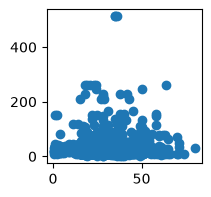

In [57]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'],df['Fare'])

In [58]:
sns.pairplot()

TypeError: pairplot() missing 1 required positional argument: 'data'

<Axes: >

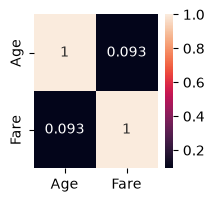

In [60]:
corr=df[num_cols].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)